In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
file= "/content/uber.xlsx"
df= pd.read_excel(file)
df.head()

,pickup_dt,borough,pickups,spd,vsb,temp,dewp,slp,pcp01,pcp06,pcp24,sd,hday
0,2015-01-01 01:00:00,Bronx,152,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y
1,2015-01-01 01:00:00,Brooklyn,1519,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y
2,2015-01-01 01:00:00,EWR,0,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y
3,2015-01-01 01:00:00,Manhattan,5258,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y
4,2015-01-01 01:00:00,Queens,405,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y


In [ ]:
df.sample(50)

,pickup_dt,borough,pickups,spd,vsb,temp,dewp,slp,pcp01,pcp06,pcp24,sd,hday
9744,2015-03-03 05:00:00,Staten Island,0,6.00,10.0,27.000000,9.000000,1028.5,0.00,0.000000,0.000000,15.000000,N
3928,2015-01-25 20:00:00,Brooklyn,621,10.00,10.0,42.000000,11.000000,1008.5,0.00,0.010000,0.600000,2.375000,N
14904,2015-04-04 13:00:00,Staten Island,0,13.00,10.0,47.000000,32.000000,1006.9,0.00,0.138333,0.000000,0.000000,N
13090,2015-03-24 03:00:00,Manhattan,256,6.50,10.0,32.000000,3.000000,1024.1,0.00,0.058333,0.000000,0.000000,N
21846,2015-05-17 14:00:00,NaN,1,4.25,7.5,72.000000,65.500000,1021.2,0.00,0.000000,0.000000,0.000000,N
12241,2015-03-18 19:00:00,EWR,0,14.00,10.0,36.000000,9.000000,1016.7,0.00,0.000000,0.560000,0.000000,N
3272,2015-01-21 17:00:00,Queens,204,5.00,10.0,32.000000,7.000000,1021.3,0.00,0.000000,0.000000,0.000000,N
27389,2015-06-20 12:00:00,Brooklyn,962,8.00,10.0,67.000000,51.000000,1018.6,0.00,0.000000,0.000000,0.000000,N
25156,2015-06-06 20:00:00,NaN,6,9.00,10.0,75.000000,48.000000,1014.7,0.00,0.305000,0.000000,0.000000,N
27604,2015-06-21 19:00:00,EWR,0,10.00,10.0,85.000000,66.000000,1006.4,0.00,0.102500,0.000000,0.000000,N


In [ ]:
missing=df.isna().sum()
missing

,0
pickup_dt,0
borough,3043
pickups,0
spd,0
vsb,0
temp,0
dewp,0
slp,0
pcp01,0
pcp06,0


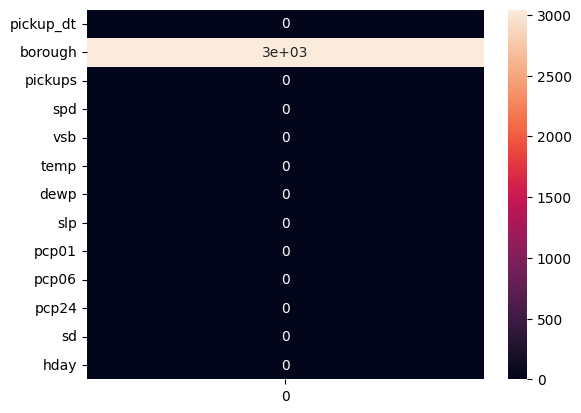

In [ ]:
sns.heatmap(missing.to_frame(), annot=True)
plt.show()

In [ ]:
#datetime extractions
df['pickup_dt'] = pd.to_datetime(df['pickup_dt'])

# Extract features
df['hour'] = df['pickup_dt'].dt.hour
df['day'] = df['pickup_dt'].dt.day
df['month'] = df['pickup_dt'].dt.month
df['day_of_week'] = df['pickup_dt'].dt.dayofweek

In [ ]:
df.head()

,pickup_dt,borough,pickups,spd,vsb,temp,dewp,slp,pcp01,pcp06,pcp24,sd,hday,hour,day,month,day_of_week
0,2015-01-01 01:00:00,Bronx,152,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y,1,1,1,3
1,2015-01-01 01:00:00,Brooklyn,1519,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y,1,1,1,3
2,2015-01-01 01:00:00,EWR,0,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y,1,1,1,3
3,2015-01-01 01:00:00,Manhattan,5258,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y,1,1,1,3
4,2015-01-01 01:00:00,Queens,405,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y,1,1,1,3


In [ ]:
if 'borough' in df.columns:
    df = pd.get_dummies(df, columns=['borough'], drop_first=True,dtype=int)
df

,pickup_dt,pickups,spd,vsb,temp,dewp,slp,pcp01,pcp06,pcp24,...,hday,hour,day,month,day_of_week,borough_Brooklyn,borough_EWR,borough_Manhattan,borough_Queens,borough_Staten Island
0,2015-01-01 01:00:00,152,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,...,Y,1,1,1,3,0,0,0,0,0
1,2015-01-01 01:00:00,1519,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,...,Y,1,1,1,3,1,0,0,0,0
2,2015-01-01 01:00:00,0,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,...,Y,1,1,1,3,0,1,0,0,0
3,2015-01-01 01:00:00,5258,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,...,Y,1,1,1,3,0,0,1,0,0
4,2015-01-01 01:00:00,405,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,...,Y,1,1,1,3,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29096,2015-06-30 23:00:00,0,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,...,N,23,30,6,1,0,1,0,0,0
29097,2015-06-30 23:00:00,3828,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,...,N,23,30,6,1,0,0,1,0,0
29098,2015-06-30 23:00:00,580,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,...,N,23,30,6,1,0,0,0,1,0
29099,2015-06-30 23:00:00,0,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,...,N,23,30,6,1,0,0,0,0,1


In [ ]:
df['is_raining'] = (df['pcp01'] > 0).astype(int)
df['heavy_rain']= (df['pcp24']>0).astype(int)
df.head()

,pickup_dt,pickups,spd,vsb,temp,dewp,slp,pcp01,pcp06,pcp24,...,day,month,day_of_week,borough_Brooklyn,borough_EWR,borough_Manhattan,borough_Queens,borough_Staten Island,is_raining,heavy_rain
0,2015-01-01 01:00:00,152,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,...,1,1,3,0,0,0,0,0,0,0
1,2015-01-01 01:00:00,1519,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,...,1,1,3,1,0,0,0,0,0,0
2,2015-01-01 01:00:00,0,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,...,1,1,3,0,1,0,0,0,0,0
3,2015-01-01 01:00:00,5258,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,...,1,1,3,0,0,1,0,0,0,0
4,2015-01-01 01:00:00,405,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,...,1,1,3,0,0,0,1,0,0,0


In [ ]:
mean_temp=df['temp'].mean()

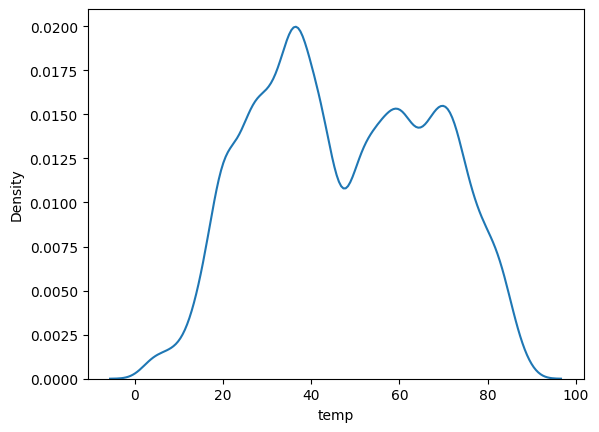

In [ ]:
sns.kdeplot(df['temp'])
plt.show()

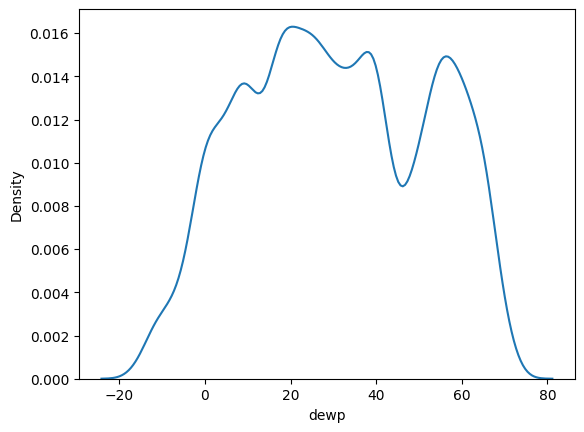

In [ ]:
sns.kdeplot(df['dewp'])
plt.show()

In [ ]:
df['high_temp']=(df['temp']>mean_temp).astype(int)
df['high_dew']= (df['dewp']>(df['dewp'].mean())).astype(int)
df.head()

,pickup_dt,pickups,spd,vsb,temp,dewp,slp,pcp01,pcp06,pcp24,...,day_of_week,borough_Brooklyn,borough_EWR,borough_Manhattan,borough_Queens,borough_Staten Island,is_raining,heavy_rain,high_temp,high_dew
0,2015-01-01 01:00:00,152,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,...,3,0,0,0,0,0,0,0,0,0
1,2015-01-01 01:00:00,1519,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,...,3,1,0,0,0,0,0,0,0,0
2,2015-01-01 01:00:00,0,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,...,3,0,1,0,0,0,0,0,0,0
3,2015-01-01 01:00:00,5258,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,...,3,0,0,1,0,0,0,0,0,0
4,2015-01-01 01:00:00,405,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,...,3,0,0,0,1,0,0,0,0,0


In [ ]:
df['vsb'].mean()

np.float64(8.818124896706218)

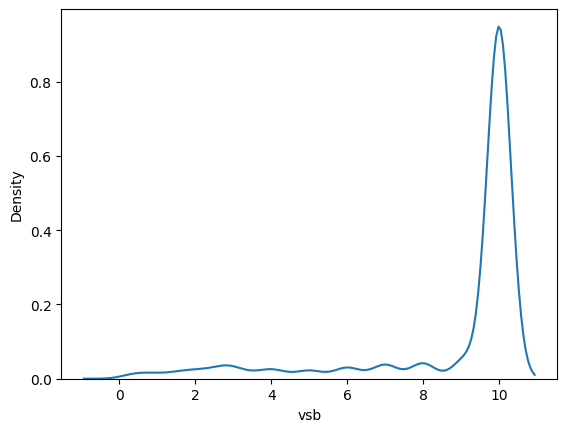

In [ ]:
sns.kdeplot(df['vsb'])
plt.show()

In [ ]:
vsb_mean= df['vsb'].mean()
df['low_vsb']=(df['vsb']<vsb_mean).astype(int)
df.head()

,pickup_dt,pickups,spd,vsb,temp,dewp,slp,pcp01,pcp06,pcp24,...,borough_Brooklyn,borough_EWR,borough_Manhattan,borough_Queens,borough_Staten Island,is_raining,heavy_rain,high_temp,high_dew,low_vsb
0,2015-01-01 01:00:00,152,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,2015-01-01 01:00:00,1519,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,...,1,0,0,0,0,0,0,0,0,0
2,2015-01-01 01:00:00,0,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,...,0,1,0,0,0,0,0,0,0,0
3,2015-01-01 01:00:00,5258,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,...,0,0,1,0,0,0,0,0,0,0
4,2015-01-01 01:00:00,405,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,...,0,0,0,1,0,0,0,0,0,0


In [ ]:
mean_wsp= df['spd'].mean()
df['high_speed']=(df['spd']>mean_wsp).astype(int)
df.sample(10)

,pickup_dt,pickups,spd,vsb,temp,dewp,slp,pcp01,pcp06,pcp24,...,borough_EWR,borough_Manhattan,borough_Queens,borough_Staten Island,is_raining,heavy_rain,high_temp,high_dew,low_vsb,high_speed
25422,2015-06-08 11:00:00,418,3.000000,10.00,64.000000,53.000000,1016.8,0.00,0.120000,0.000000,...,0,0,1,0,0,0,1,1,0,0
22976,2015-05-24 12:00:00,3,5.500000,10.00,59.000000,43.000000,1028.1,0.00,0.000000,0.083333,...,0,0,0,1,0,1,1,1,0,0
13448,2015-03-26 09:00:00,0,5.000000,6.50,45.000000,39.500000,1016.2,0.00,0.000000,0.208333,...,1,0,0,0,0,1,0,1,1,0
9159,2015-02-27 14:00:00,0,4.000000,10.00,19.000000,4.000000,1028.5,0.00,0.000000,0.000000,...,1,0,0,0,0,0,0,0,0,0
11822,2015-03-16 04:00:00,0,10.000000,10.00,37.000000,22.000000,1015.4,0.00,0.000000,0.000000,...,1,0,0,0,0,0,0,0,0,1
11262,2015-03-12 16:00:00,340,9.000000,10.00,44.000000,0.000000,1030.2,0.00,0.000000,0.000000,...,0,0,1,0,0,0,0,0,0,1
6016,2015-02-08 00:00:00,102,0.000000,10.00,38.000000,20.000000,1016.7,0.00,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0
24321,2015-06-01 18:00:00,72,13.000000,5.00,55.000000,52.000000,1019.9,0.00,0.210000,0.000000,...,0,0,0,0,0,0,1,1,1,1
24628,2015-06-03 15:00:00,2655,3.333333,10.00,61.666667,50.333333,1023.9,0.00,0.000000,0.000000,...,0,1,0,0,0,0,1,1,0,0
454,2015-01-03 21:00:00,342,7.000000,1.65,35.000000,32.000000,1031.0,0.06,0.383333,0.753000,...,0,0,1,0,1,1,0,1,1,1


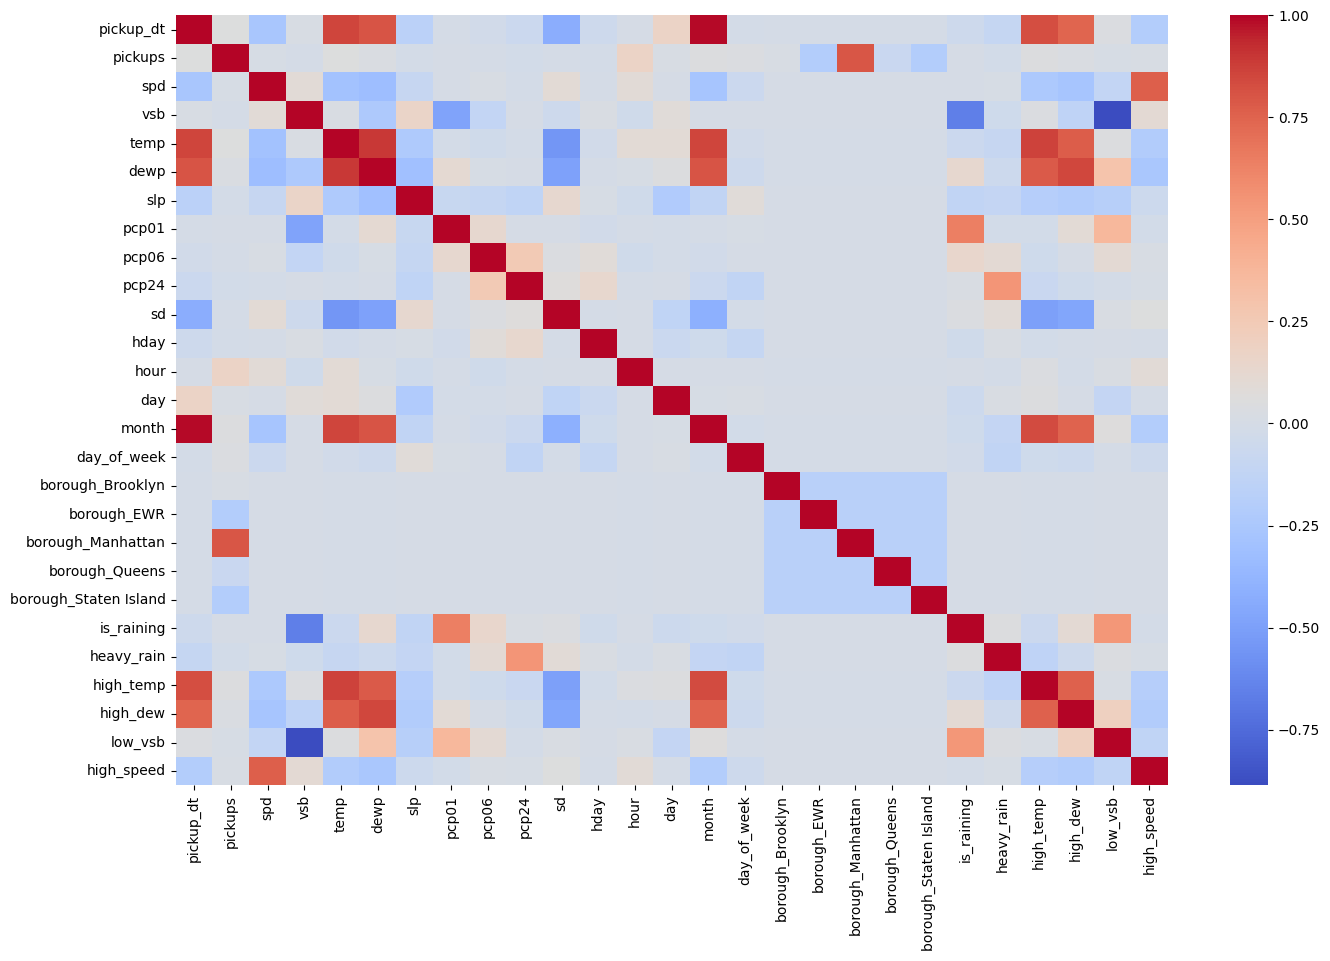

In [ ]:
df['hday']=df['hday'].map({'N':0,'Y':1}) #or use ohe

corr_matrix = df.corr()
plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.show()

In [ ]:

df.corr()['pickups'].sort_values(ascending=True)

,pickups
borough_EWR,-0.206207
borough_Staten Island,-0.205544
borough_Queens,-0.076082
heavy_rain,-0.020601
pcp24,-0.020219
slp,-0.015011
hday,-0.010658
sd,-0.008241
vsb,-0.007484
pcp06,-0.002909


skewness

In [ ]:
df['heavy_rain'].skew()


np.float64(0.584351738628926)

In [ ]:
df['high_temp'].skew()

np.float64(0.05479812856322791)

In [ ]:
df['high_dew'].skew()

np.float64(0.0443415513926771)

<Axes: >

<Figure size 1600x600 with 0 Axes>

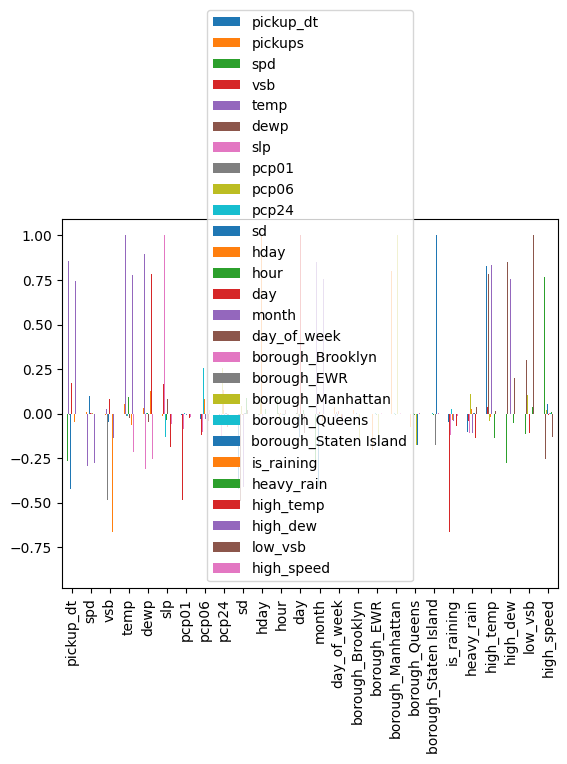

In [ ]:
plt.figure(figsize=(16, 6))
df.corr().drop(['pickups']).plot(kind='bar')

FEATURE VS TARGET (BIVARIATE)


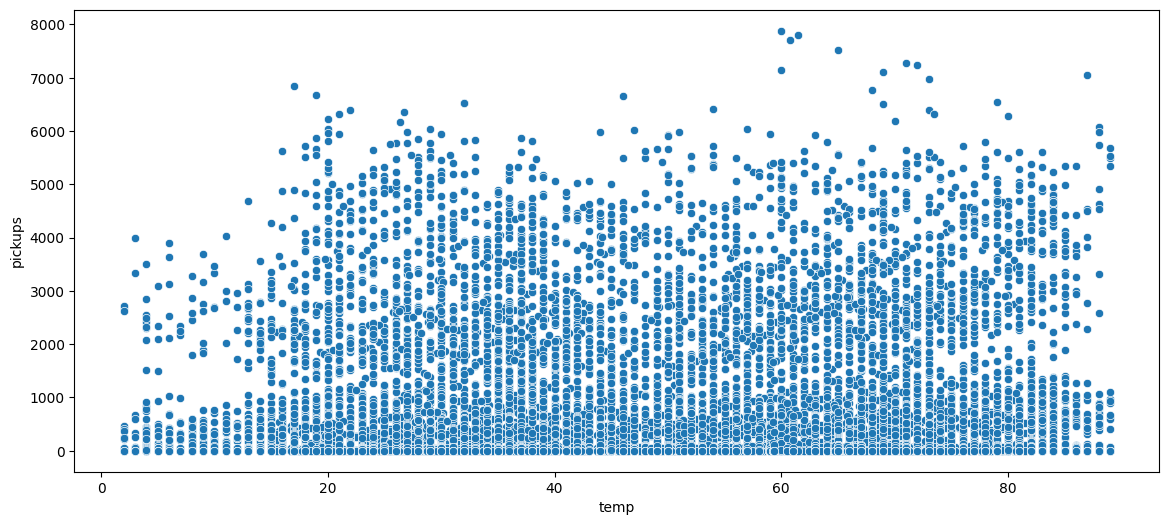

In [ ]:
plt.figure(figsize=(14, 6))
sns.scatterplot(x='temp',y='pickups',data=df)
plt.show()


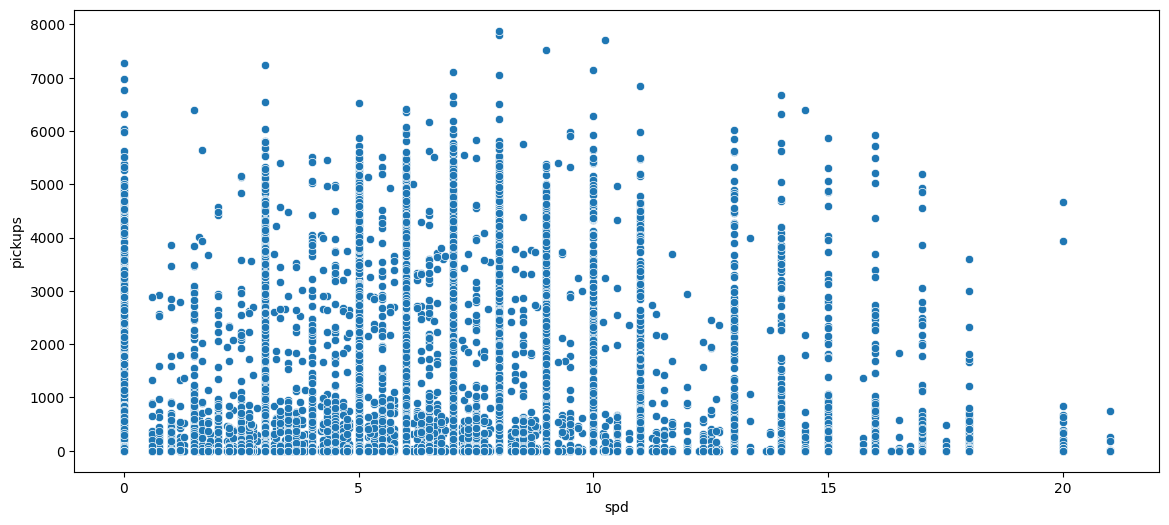

In [ ]:
plt.figure(figsize=(14, 6))
sns.scatterplot(x='spd',y='pickups',data=df)
plt.show()
#low importance feature

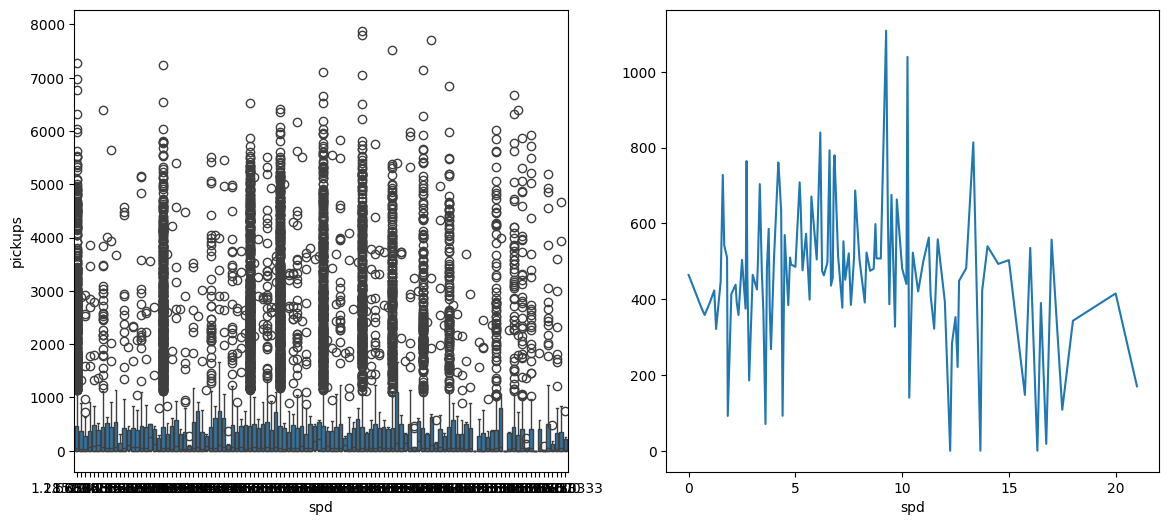

In [ ]:
fig,axes= plt.subplots(1,2,figsize=(14,6))
sns.boxplot(x='spd',y='pickups',data=df,ax=axes[0])
df.groupby('spd')['pickups'].mean().plot(ax=axes[1])
plt.show()
#outliers but not bad .. they show the peak hours and how maximum pickups
#althugh shows  spd alone is a weak feature ..

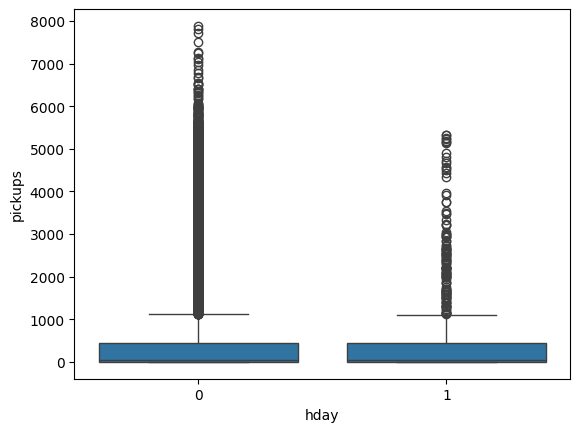

In [ ]:
sns.boxplot(x='hday',y='pickups',data=df)
plt.show()
#shows the extreme cases in cases of holidays..    on a non holiday we get less pickups  than a holiday.

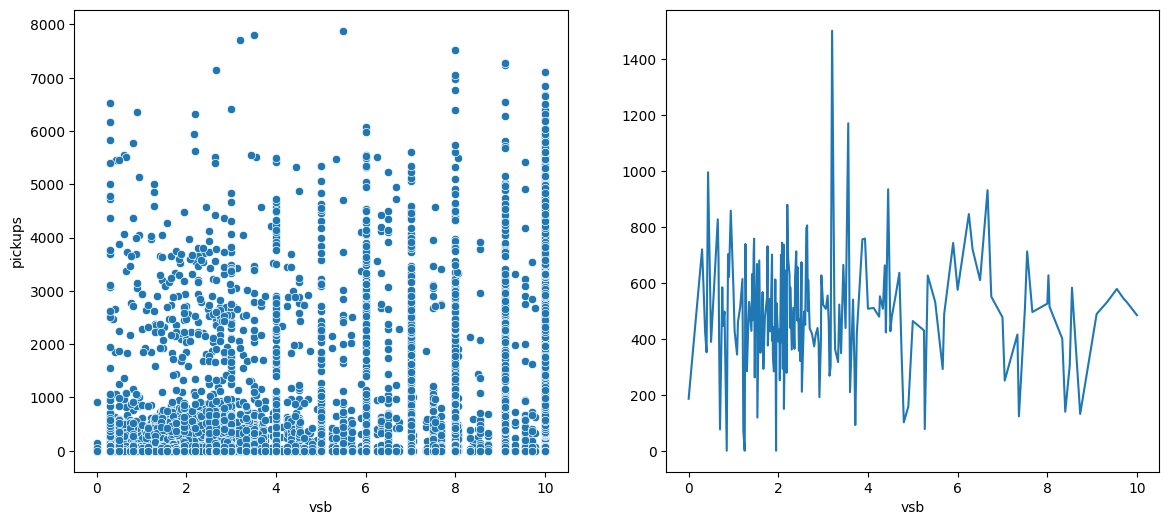

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.scatterplot(x='vsb', y='pickups', data=df, ax=axes[0])
df.groupby('vsb')['pickups'].mean().plot(ax=axes[1])

plt.show()

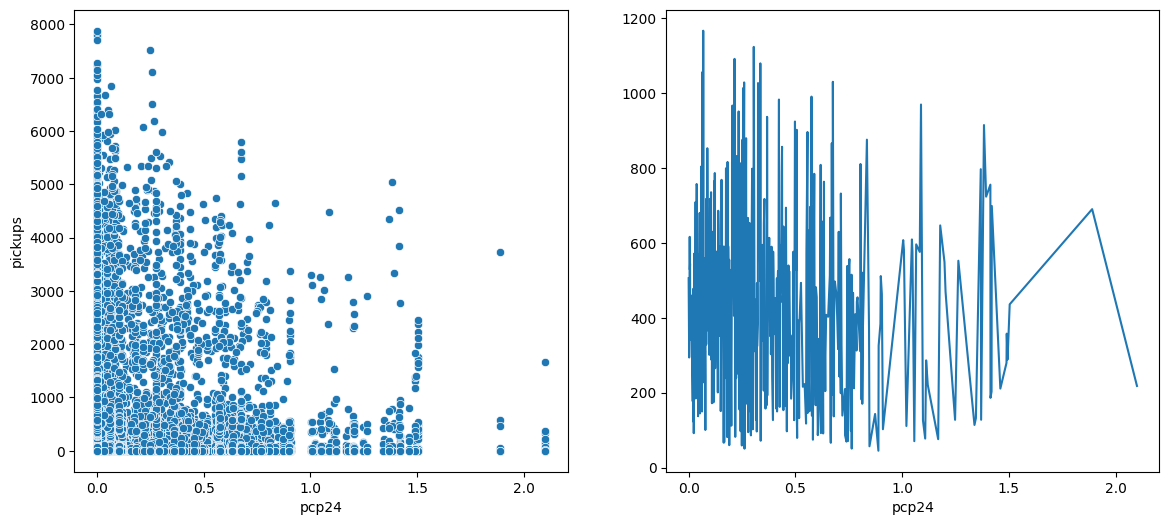

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
sns.scatterplot(x='pcp24',y='pickups',data=df,ax=axes[0])
df.groupby('pcp24')['pickups'].mean().plot(ax=axes[1])
plt.show()
#during heavy rainfall. some pickups reach beyond 7000-8000 range..

Hourly pickups


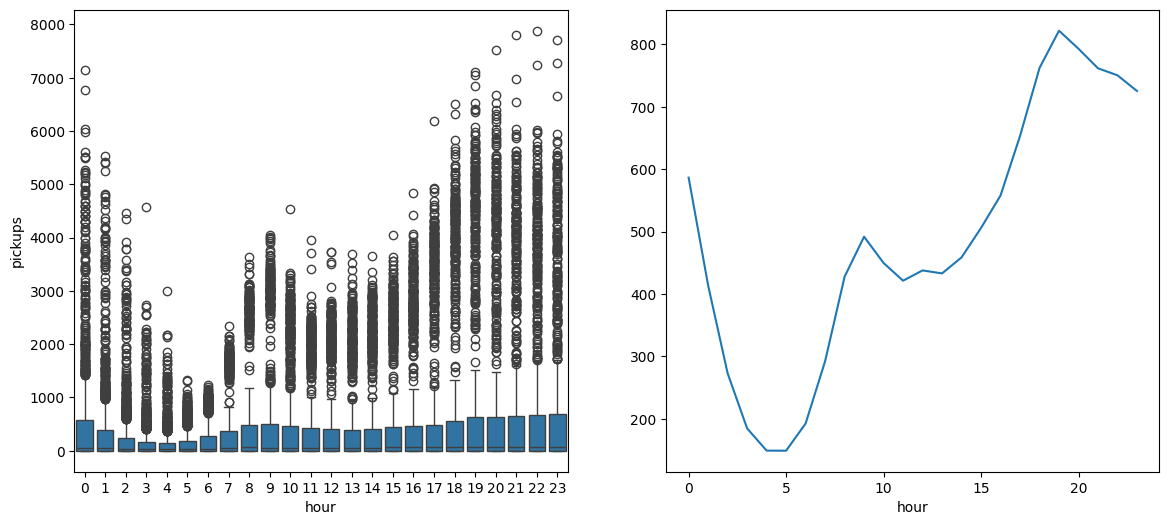

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
sns.boxplot(x='hour',y='pickups',data=df,ax=axes[0])
df.groupby('hour')['pickups'].mean().plot(ax=axes[1])
plt.show()
#morning hour rush
#boxes show the q1,median,q3 and the outliers.. show the extreme pickups ... relatively less pickups during 3-6 hours.. with maximum pickups during the ~20th hour

DAY OF THE WEEK VS PICKUPS

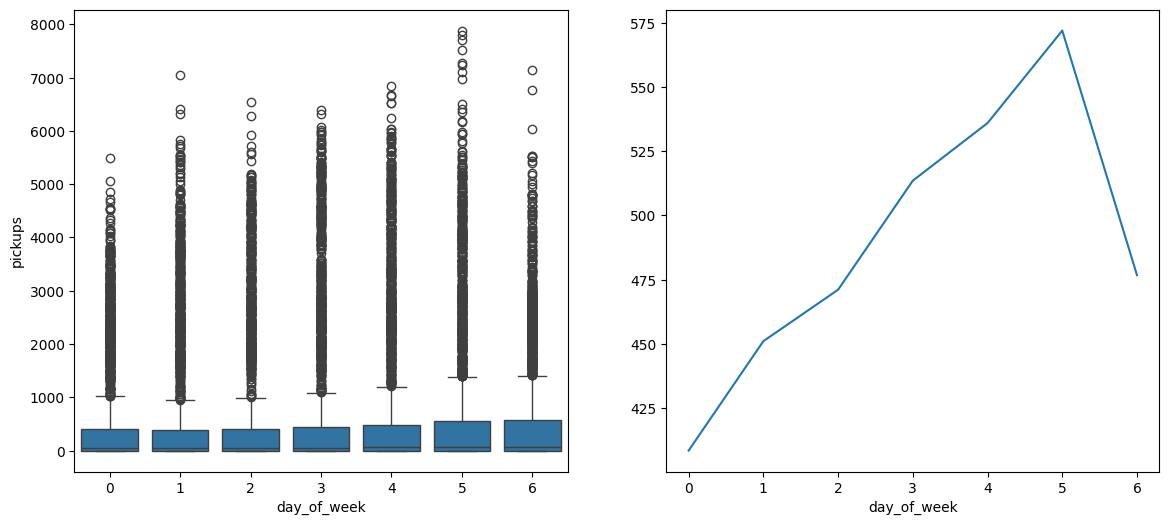

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
sns.boxplot(x='day_of_week',y='pickups',data=df,ax=axes[0])
df.groupby('day_of_week')['pickups'].mean().plot()
plt.show()
#considerable hike during friday .. weekend .. and again sttep decline in saturday

In [ ]:
df.corr()['hour']

,hour
pickup_dt,0.004845
pickups,0.167979
spd,0.093306
vsb,-0.036929
temp,0.093750
dewp,0.005376
slp,-0.033262
pcp01,-0.004420
pcp06,-0.037576
pcp24,-0.007823


In [ ]:
df.groupby('borough_Brooklyn')['pickups'].describe()


,count,mean,std,min,25%,50%,75%,max
borough_Brooklyn,,,,,,,,
0,24758.0,482.459730,1072.181771,0.0,1.0,20.0,326.75,7883.0
1,4343.0,534.431269,294.810182,0.0,331.5,493.0,675.00,2009.0


adding further features

In [ ]:
df['rush_hour']=df['hour'].isin([7,8,9,1,18,19,20]).astype(int)
df['bad_weather']=((df['is_raining']==1)|(df['heavy_rain']==1)).astype(int)
df['nightlife']=df['hour'].isin([20,21,22,23]).astype(int)
df.head()



,pickup_dt,pickups,spd,vsb,temp,dewp,slp,pcp01,pcp06,pcp24,...,rush_hour,bad_weather,nightlife,lag_1,lag_2,lag_24,rolling_mean_3,rolling_mean_6,borough,errors
0,2015-01-01 01:00:00,152,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,...,1,0,0,NaN,NaN,NaN,NaN,NaN,borough_Brooklyn,NaN
1,2015-01-01 01:00:00,1519,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,...,1,0,0,152.0,NaN,NaN,NaN,NaN,borough_Brooklyn,NaN
2,2015-01-01 01:00:00,0,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,...,1,0,0,1519.0,152.0,NaN,557.000000,NaN,borough_EWR,NaN
3,2015-01-01 01:00:00,5258,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,...,1,0,0,0.0,1519.0,NaN,2259.000000,NaN,borough_Manhattan,NaN
4,2015-01-01 01:00:00,405,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,...,1,0,0,5258.0,0.0,NaN,1887.666667,NaN,borough_Queens,NaN


time based

In [ ]:
df['lag_1']=df['pickups'].shift(1)
df['lag_2']=df['pickups'].shift(2)
df['lag_24']=df['pickups'].shift(24)


In [ ]:
df.dropna()

,pickup_dt,pickups,spd,vsb,temp,dewp,slp,pcp01,pcp06,pcp24,...,high_temp,high_dew,low_vsb,high_speed,rush_hour,bad_weather,nightlife,lag_1,lag_2,lag_24
24,2015-01-01 04:00:00,3003,5.0,10.0,29.0,9.0,1022.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0.0,1390.0,152.0
25,2015-01-01 04:00:00,344,5.0,10.0,29.0,9.0,1022.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,3003.0,0.0,1519.0
26,2015-01-01 04:00:00,5,5.0,10.0,29.0,9.0,1022.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,344.0,3003.0,0.0
27,2015-01-01 04:00:00,2,5.0,10.0,29.0,9.0,1022.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,5.0,344.0,5258.0
28,2015-01-01 05:00:00,87,5.0,10.0,28.0,9.0,1021.8,0.0,0.0,0.0,...,0,0,0,0,0,0,0,2.0,5.0,405.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29096,2015-06-30 23:00:00,0,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,...,1,1,0,1,0,0,0,990.0,67.0,417.0
29097,2015-06-30 23:00:00,3828,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,...,1,1,0,1,0,0,0,0.0,990.0,3.0
29098,2015-06-30 23:00:00,580,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,...,1,1,0,1,0,0,0,3828.0,0.0,4.0
29099,2015-06-30 23:00:00,0,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,...,1,1,0,1,0,0,0,580.0,3828.0,66.0


In [ ]:
df['rolling_mean_3']=df['pickups'].rolling(window=3).mean()
df['rolling_mean_6']=df['pickups'].rolling(window=6).mean()
df.head()

,pickup_dt,pickups,spd,vsb,temp,dewp,slp,pcp01,pcp06,pcp24,...,rush_hour,bad_weather,nightlife,lag_1,lag_2,lag_24,rolling_mean_3,rolling_mean_6,borough,errors
0,2015-01-01 01:00:00,152,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,...,1,0,0,NaN,NaN,NaN,NaN,NaN,borough_Brooklyn,NaN
1,2015-01-01 01:00:00,1519,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,...,1,0,0,152.0,NaN,NaN,NaN,NaN,borough_Brooklyn,NaN
2,2015-01-01 01:00:00,0,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,...,1,0,0,1519.0,152.0,NaN,557.000000,NaN,borough_EWR,NaN
3,2015-01-01 01:00:00,5258,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,...,1,0,0,0.0,1519.0,NaN,2259.000000,NaN,borough_Manhattan,NaN
4,2015-01-01 01:00:00,405,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,...,1,0,0,5258.0,0.0,NaN,1887.666667,NaN,borough_Queens,NaN


AREA VISE HOURLY PICKUPS

In [ ]:
df['borough']=df.filter(like='borough_').idxmax(axis=1)
df['borough'].str.replace('borough_', '')

,borough
0,Brooklyn
1,Brooklyn
2,EWR
3,Manhattan
4,Queens
...,...
29096,EWR
29097,Manhattan
29098,Queens
29099,Staten Island


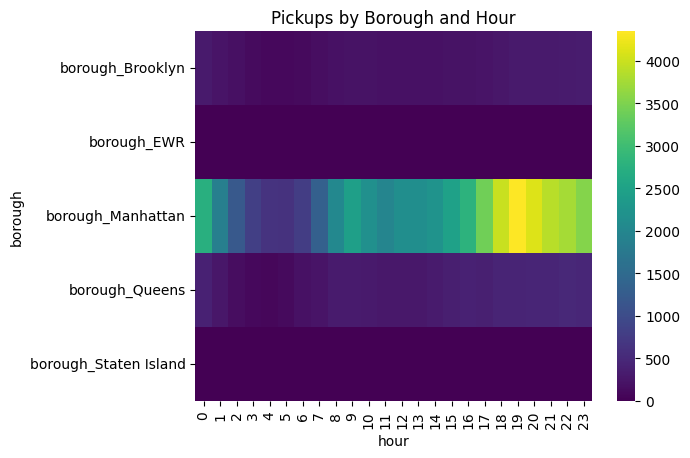

In [ ]:
#categorical vs categorical
pivot = df.pivot_table(values='pickups', index='borough', columns='hour', aggfunc='mean')

sns.heatmap(pivot, cmap='viridis')
plt.title("Pickups by Borough and Hour")
plt.show()

In [ ]:
pivot2= df.pivot_table(values='pickups', index='day_of_week', columns='hour', aggfunc='mean')
pivot2

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_of_week,,,,,,,,,,,,,,,,,,,,,
0,363.600000,228.915663,132.282209,82.624242,86.952096,146.628743,220.480000,336.802198,492.631285,565.293785,...,396.758621,455.622093,491.245614,536.880000,652.415205,656.502825,619.398844,586.617143,560.582857,469.442529
1,335.757396,200.425150,116.128834,71.748428,67.329268,113.313609,193.908571,337.812155,526.937500,593.926136,...,399.436782,460.177143,517.660920,623.582857,772.931429,854.936047,775.175141,755.634286,717.179775,628.511765
2,410.337349,234.325153,135.025641,81.006452,77.396226,118.237805,204.445783,352.837209,534.523256,583.774566,...,412.765060,463.292398,536.502924,650.844311,778.958333,892.493902,817.535294,810.550898,769.204678,686.443787
3,482.042683,300.352941,180.381818,130.487805,115.115152,144.668675,210.942857,354.733333,531.161111,592.932584,...,438.005714,503.954545,571.231214,694.728324,814.050279,909.642458,877.910112,879.369318,883.855556,827.101695
4,650.605882,370.105263,209.269006,135.132530,123.820359,149.206897,214.754286,339.550000,506.305556,582.592179,...,471.902857,526.920904,587.910615,697.803371,823.272727,926.916667,940.279330,876.915730,861.348315,952.398876
5,884.834254,715.182857,485.067797,346.662791,260.690476,182.432927,159.192771,167.976331,217.273256,293.141243,...,551.170455,572.898305,633.320225,759.972376,839.745763,903.170330,950.848315,896.625698,899.928177,983.430168
6,935.594444,807.146893,608.680000,412.050847,300.643678,189.277108,141.267857,140.267857,168.747059,230.551136,...,536.727273,555.422857,562.805556,605.178771,650.271186,612.240223,564.460674,528.527778,549.367816,513.960227


In [ ]:
pivot3= df.pivot_table(values='pickups', index='rush_hour', columns='hour', aggfunc='mean')
pivot3
#

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
rush_hour,,,,,,,,,,,,,,,,,,,,,
0,586.480498,NaN,273.058974,184.791019,149.18299,149.011966,192.593333,NaN,NaN,NaN,...,458.685033,505.87408,557.840946,653.135993,NaN,NaN,NaN,761.582927,750.351657,725.228128
1,NaN,413.823381,NaN,NaN,NaN,NaN,NaN,292.251623,427.715216,491.804207,...,NaN,NaN,NaN,NaN,762.089125,821.782644,792.900243,NaN,NaN,NaN


In [ ]:
df['rush_hour'].value_counts()

,count
rush_hour,
0,20526
1,8575


In [ ]:
df2=df.dropna()

In [ ]:
x= df2.drop(['pickup_dt','pickups','borough'],axis=1)
y=df2['pickups']


MODELLING using random forest regressor


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import roc_auc_score, accuracy_score, r2_score,root_mean_squared_error


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.80, random_state=42)

In [ ]:
model= RandomForestRegressor(n_estimators=100,random_state=42)
model.fit(x_train,y_train)


RandomForestRegressor(random_state=42)

In [ ]:
ypred=model.predict(x_test)
ypred

array([2.05040e+03, 6.29860e+02, 4.10000e-01, ..., 1.02266e+03,
       7.96000e+01, 3.12000e+00])

In [ ]:
ypred

array([2.05040e+03, 6.29860e+02, 4.10000e-01, ..., 1.02266e+03,
       7.96000e+01, 3.12000e+00])

In [ ]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, ypred)
print(f"R-squared score: {r2}")

R-squared score: 0.9995802822916038


In [ ]:
root_mean_squared_error(y_test,ypred)

19.969220267230153

In [ ]:
results = pd.DataFrame({'Actual': y_test.reset_index(drop=True), 'Predicted': ypred})
display(results.head(10))

,Actual,Predicted
0,2056,2050.40
1,631,629.86
2,0,0.41
3,0,0.00
4,91,91.60
5,0,1.63
6,3,2.37
7,184,184.55
8,22,23.44
9,0,2.12


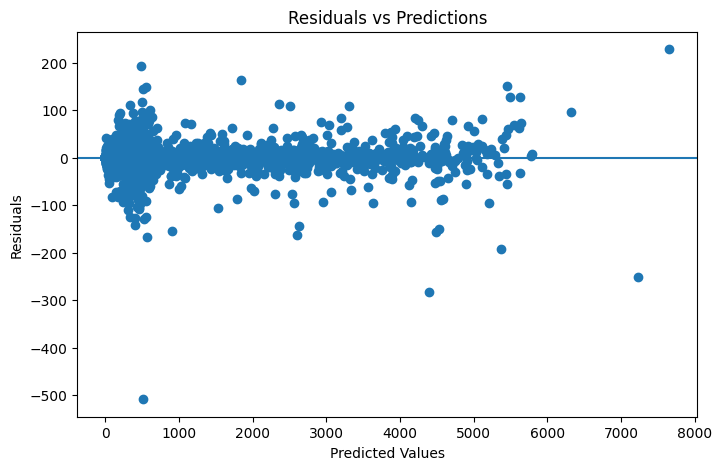

In [ ]:
import matplotlib.pyplot as plt


ypred = model.predict(x_test)

# residuals
residuals = y_test- ypred

plt.figure(figsize=(8,5))
plt.scatter(ypred, residuals)
plt.axhline(y=0)  # reference line
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predictions")
plt.show()

USE XGBOOST

In [ ]:
from xgboost import XGBRegressor

model2 = XGBRegressor()
model2.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [ ]:
y_pred

array([2.05213e+03, 6.30310e+02, 4.20000e-01, ..., 1.02346e+03,
       8.06300e+01, 3.06000e+00])

In [ ]:
r2_score(y_test,y_pred)

0.9995840969551396

In [ ]:
root_mean_squared_error(y_test,y_pred)
#error  is lesser in xgboost regressor

19.878266598061405

In [ ]:
model2.feature_importances_

array([9.1087186e-06, 1.2750430e-05, 9.4776260e-05, 1.1065103e-05,
       2.2813689e-05, 4.3020023e-05, 1.3487962e-05, 8.9444229e-06,
       1.5603626e-05, 5.8916299e-05, 1.1300429e-04, 2.1689795e-05,
       2.1527804e-04, 2.2744796e-04, 9.5107004e-02, 2.3167809e-04,
       8.4412342e-01, 1.4631898e-03, 4.2270150e-07, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 4.2884431e-06, 0.0000000e+00,
       3.6342524e-03, 5.5948069e-04, 5.1026029e-05, 4.8288323e-02,
       5.5634417e-03, 1.0566020e-04], dtype=float32)

checking overfitting

In [ ]:
print("Train R2:", model2.score(x_train, y_train))
print("Test R2:", model2.score(x_test, y_test))
#using test data.. model error explains 99.95 percent of variance.. whereas in train its 99.99 percent

Train R2: 0.9999133944511414
Test R2: 0.9995020627975464


residuals vs prediction plot
XGBOOST

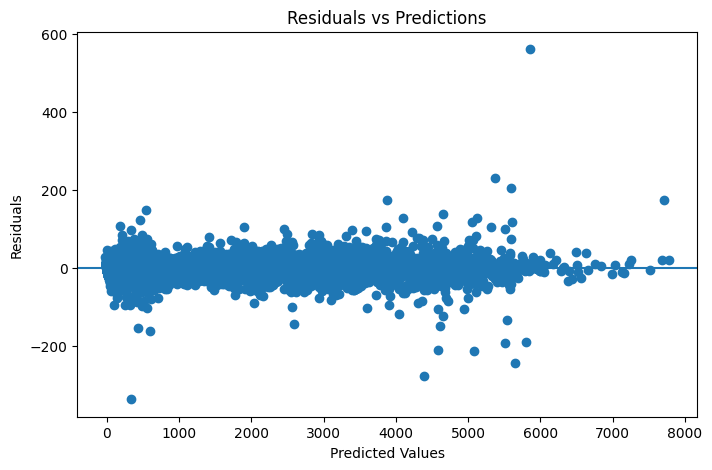

In [ ]:
import matplotlib.pyplot as plt


y_pred = model2.predict(x)

residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0)  # reference line
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predictions")
plt.show()
#shows  model doesnt follow any curve or pattern.. and is reliable
#showa basically the predicted value vs the error.. residuals

ERROR ANALYSIS BASED ON NEW FEATURES



In [ ]:
df['errors']=residuals
df.groupby('vsb')['errors'].mean()
#for vsb of around 9.755.. the model performs poorly

,errors
vsb,
0.000000,3.450300
0.300000,-1.136144
0.333333,6.798144
0.366667,32.165031
0.400000,0.066162
...,...
9.333333,-0.277005
9.550000,11.789964
9.700000,-3.357209


In [ ]:
pcp_model_error=df.groupby('pcp24')['errors'].mean()
pcp_model_error


,errors
pcp24,
0.000000,-0.493793
0.002500,5.582174
0.003333,2.524500
0.005000,23.396012
0.005833,0.723275
...,...
1.490000,-2.542629
1.493833,4.279739
1.503833,-2.381394


In [ ]:
df.groupby('hday')['errors'].mean()
#holidays result in greater error in the prediction of pickup values

,errors
hday,
0,-0.334033
1,1.258752


In [ ]:
df.groupby('spd')['errors'].mean()

,errors
spd,
0.00,-1.012983
0.60,3.994179
0.75,2.386015
1.00,-1.076203
1.20,-15.675108
...,...
17.00,-0.715313
17.50,-2.530141
18.00,-3.706525


CHECK MODEL CHOICE

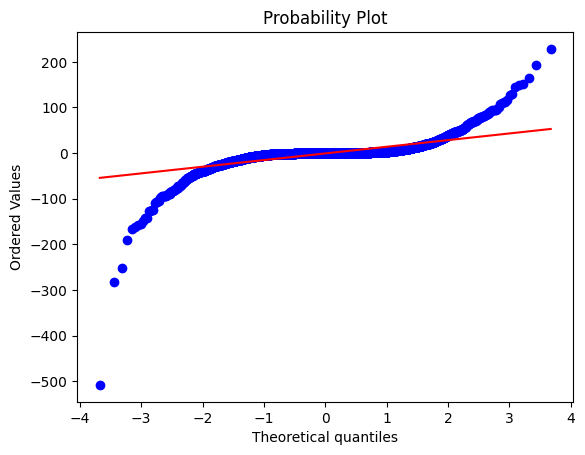

In [ ]:
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.show()
#At the middle portion. .the model follows the line which states that the errors are normally distributed.. and is not much.. at extreme values.. there are extreme cases outliers are there in terns of pikups.. Q-Q plot helps us understand the extreme cases leptokurtosis case